In [1]:
# Cell 1 — Imports  (pyarrow MUST be first: Windows DLL fix)
import pyarrow
import transformers
import torch
import os, sys, json
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm

print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

torch 2.5.1+cu121 | CUDA: True


In [2]:
# Cell 2 — Config, load model and probe_llama.pkl
from dotenv import load_dotenv
load_dotenv('../.env')
from src.utils.model_loader import get_model
from src.probing.faithfulness_detector import FaithfulnessProbe

MODEL_NAME      = 'meta-llama/Llama-3.1-8B-Instruct'
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT_DIR         = '../outputs'
ALPHA           = 5.0
STEERING_METHOD = 'M1'   # 'M1' = probe direction, 'M2' = mean-difference
MAX_TOKENS      = 30
N_TEST          = 5
NLDD_THRESHOLD  = 0.1
PROBE_PATH      = os.path.join(OUT_DIR, 'probe_llama.pkl')

print(f'Loading {MODEL_NAME} ...')
model = get_model(MODEL_NAME, device=DEVICE)
print(f'Loaded  layers={model.cfg.n_layers}  d_model={model.cfg.d_model}')

if not os.path.exists(PROBE_PATH):
    raise FileNotFoundError(f'{PROBE_PATH} not found — run notebook 05 first.')
probe = FaithfulnessProbe.load(PROBE_PATH)
print(f'Loaded probe from {PROBE_PATH}  (layer={probe.layer})')

meta_path = os.path.join(OUT_DIR, 'probe_llama_meta.json')
if os.path.exists(meta_path):
    with open(meta_path) as f:
        probe_meta = json.load(f)
    print('Probe meta:', probe_meta)
else:
    probe_meta = {}

steering_layer = probe.layer
print(f'Steering layer: {steering_layer}  |  alpha: {ALPHA}  |  method: {STEERING_METHOD}')

Loading meta-llama/Llama-3.1-8B-Instruct ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded  layers=32  d_model=4096
Loaded probe from ../outputs\probe_llama.pkl  (layer=8)
Probe meta: {'best_layer': 8, 'cv_accuracy_pca': 0.6098013656114214, 'cv_accuracy_raw': 0.6019987585350715, 'pca_components': 50, 'n_train': 897, 'faithful_fraction': 0.4136008918617614, 'probe_layers': [8, 12, 16, 20, 24, 28, 31], 'model': 'meta-llama/Llama-3.1-8B-Instruct'}
Steering layer: 8  |  alpha: 5.0  |  method: M1


In [3]:
# Cell 3 — Compute steering vectors
import torch.nn.functional as F
from src.probing.cot_probe import extract_cot_activations
from src.probing.faithfulness_detector import generate_faithfulness_labels
from src.steering.steering_vectors import compute_steering_vector_from_dicts, save_steering_vector
from data.dataset_loader import load_gsm8k

# Method 1: probe direction as steering vector
v_probe = probe.direction.to(DEVICE)
print(f'Method 1 (probe direction)  shape={v_probe.shape}  norm={v_probe.norm():.4f}')

# Method 2: mean-difference over calibration activations
calib_samples    = load_gsm8k(split='test', max_samples=10)
faithful_dicts   = []
unfaithful_dicts = []

for sample in tqdm(calib_samples, desc='Building steering set'):
    question, steps = sample['question'], sample['steps']
    if len(steps) < 2:
        continue
    prompt = 'Q: ' + question + ' A: ' + ' '.join(steps)
    try:
        labels = generate_faithfulness_labels(model, prompt, steps, nldd_threshold=NLDD_THRESHOLD)
    except Exception:
        continue
    acts = extract_cot_activations(model, prompt)
    for idx, is_faithful, _ in labels:
        (faithful_dicts if is_faithful else unfaithful_dicts).append(acts)

print(f'Faithful acts: {len(faithful_dicts)}  |  Unfaithful acts: {len(unfaithful_dicts)}')

if len(faithful_dicts) >= 2 and len(unfaithful_dicts) >= 2:
    v_meandiff = compute_steering_vector_from_dicts(faithful_dicts, unfaithful_dicts, layer=steering_layer)
    v_meandiff = v_meandiff.to(DEVICE)
    save_steering_vector(v_meandiff, os.path.join(OUT_DIR, 'steering_vec_llama_meandiff.pt'),
                         metadata={'layer': steering_layer, 'method': 'mean_difference', 'model': MODEL_NAME})
    print(f'Method 2 (mean-diff)  shape={v_meandiff.shape}  norm={v_meandiff.norm():.4f}')
    sim = float(F.cosine_similarity(v_probe.unsqueeze(0), v_meandiff.unsqueeze(0)))
    print(f'Cosine similarity (probe vs mean-diff): {sim:.4f}')
else:
    print('Insufficient calibration data for Method 2.')
    v_meandiff = None

# Select steering vector based on STEERING_METHOD config
if STEERING_METHOD == 'M1':
    steering_vector = v_probe
    print(f'Using Method 1 (probe direction) as steering vector.')
elif v_meandiff is not None:
    steering_vector = v_meandiff
    print(f'Using Method 2 (mean-diff) as steering vector.')
else:
    steering_vector = v_probe
    print(f'Falling back to Method 1 (probe direction).')

print(f'Steering vector at layer {steering_layer}  |  alpha={ALPHA}')

Method 1 (probe direction)  shape=torch.Size([4096])  norm=1.0000


Building steering set:   0%|          | 0/10 [00:00<?, ?it/s]

Building steering set:  10%|█         | 1/10 [00:02<00:22,  2.45s/it]

Building steering set:  20%|██        | 2/10 [00:03<00:14,  1.87s/it]

Building steering set:  30%|███       | 3/10 [00:06<00:14,  2.07s/it]

...

Building steering set:  80%|████████  | 8/10 [00:16<00:04,  2.24s/it]

Building steering set:  90%|█████████ | 9/10 [00:20<00:02,  2.82s/it]

Building steering set: 100%|██████████| 10/10 [00:23<00:00,  2.81s/it]

Building steering set: 100%|██████████| 10/10 [00:23<00:00,  2.37s/it]

Faithful acts: 17  |  Unfaithful acts: 29
Method 2 (mean-diff)  shape=torch.Size([4096])  norm=1.0000
Cosine similarity (probe vs mean-diff): 0.0848
Using Method 1 (probe direction) as steering vector.
Steering vector at layer 8  |  alpha=5.0


In [4]:
# Cell 4 — Baseline run_pipeline on N_TEST prompts (no steering)
from src.pipeline.closed_loop import run_pipeline

test_samples = load_gsm8k(split='test', max_samples=50)
test_prompts = []
for s in test_samples:
    if len(test_prompts) >= N_TEST:
        break
    if len(s['steps']) >= 2:
        test_prompts.append('Q: ' + s['question'] + ' A: ')

print(f'Running BASELINE pipeline on {len(test_prompts)} prompts (no steering)...')
baseline_traces = []
for i, prompt in enumerate(tqdm(test_prompts, desc='Baseline')):
    trace = run_pipeline(model, prompt, probe=probe, max_tokens=MAX_TOKENS)
    baseline_traces.append(trace)
    if probe is not None and trace.confidences:
        mean_conf = float(np.mean(trace.confidences))
        print(f'  Sample {i}: mean confidence={mean_conf:.3f}  tokens={len(trace.generated_tokens)}')

print('Baseline complete.')

Running BASELINE pipeline on 5 prompts (no steering)...


Baseline:   0%|          | 0/5 [00:00<?, ?it/s]

Baseline:  20%|██        | 1/5 [00:18<01:12, 18.13s/it]

  Sample 0: mean confidence=0.821  tokens=30


Baseline:  40%|████      | 2/5 [00:35<00:53, 17.72s/it]

...

Baseline:  80%|████████  | 4/5 [01:10<00:17, 17.63s/it]

  Sample 3: mean confidence=0.831  tokens=30


Baseline: 100%|██████████| 5/5 [01:29<00:00, 18.09s/it]

Baseline: 100%|██████████| 5/5 [01:29<00:00, 17.94s/it]

  Sample 4: mean confidence=0.726  tokens=30
Baseline complete.


In [5]:
# Cell 5 — Steered run_pipeline (alpha=1.0)
print(f'Running STEERED pipeline on {len(test_prompts)} prompts (alpha={ALPHA})...')
steered_traces = []
for i, prompt in enumerate(tqdm(test_prompts, desc='Steered')):
    trace = run_pipeline(
        model, prompt,
        probe=probe,
        steering_vector=steering_vector,
        layer=steering_layer,
        max_tokens=MAX_TOKENS,
        threshold=0.5,
        alpha=ALPHA,
    )
    steered_traces.append(trace)
    n_steer = len(trace.steering_event_indices)
    print(f'  Sample {i}: steering_events={n_steer}  tokens={len(trace.generated_tokens)}')

print('Steered complete.')

Running STEERED pipeline on 5 prompts (alpha=5.0)...


Steered:   0%|          | 0/5 [00:00<?, ?it/s]

Steered:  20%|██        | 1/5 [00:17<01:11, 17.96s/it]

  Sample 0: steering_events=27  tokens=30


Steered:  40%|████      | 2/5 [00:35<00:52, 17.67s/it]

...

Steered:  80%|████████  | 4/5 [01:10<00:17, 17.62s/it]

  Sample 3: steering_events=27  tokens=30


Steered: 100%|██████████| 5/5 [01:29<00:00, 18.05s/it]

Steered: 100%|██████████| 5/5 [01:29<00:00, 17.89s/it]

  Sample 4: steering_events=26  tokens=30
Steered complete.


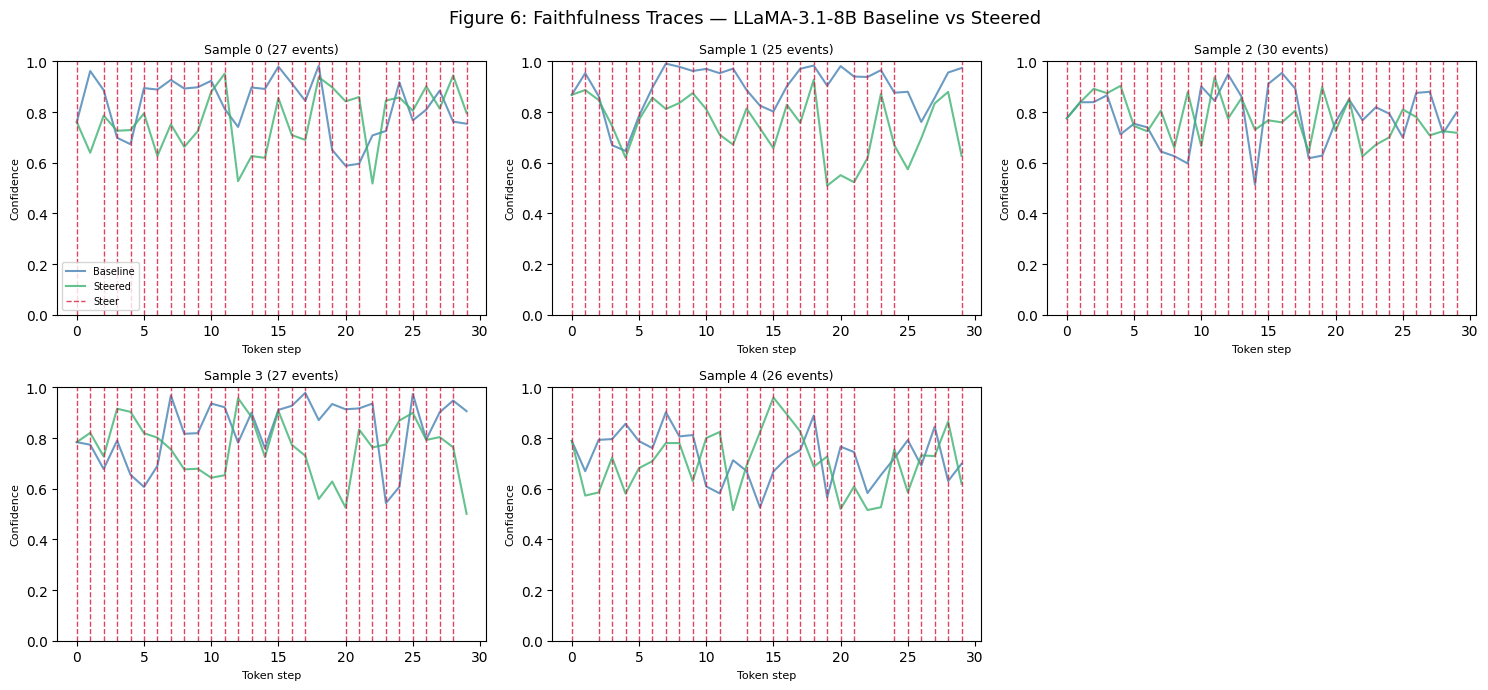

Saved -> outputs/figure6_llama_steering_traces.png
 Sample Baseline mean conf Steered mean conf  Steering events  Tokens generated
      0              0.821             0.769               27                30
      1              0.897             0.746               25                30
      2              0.781             0.775               30                30
      3              0.831             0.762               27                30
      4              0.726             0.701               26                30


In [6]:
# Cell 6 — Figure 6: faithfulness trace grid + stats table
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 7))

for idx in range(n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]
    if idx >= len(test_prompts):
        ax.axis('off')
        continue
    bt = baseline_traces[idx]
    st = steered_traces[idx]
    if not bt.confidences:
        ax.text(0.5, 0.5, 'No probe data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Sample {idx}')
        continue
    steps = range(len(bt.confidences))
    ax.plot(steps, bt.confidences, color='steelblue', lw=1.5, label='Baseline', alpha=0.8)
    if st.confidences:
        ax.plot(range(len(st.confidences)), st.confidences,
                color='mediumseagreen', lw=1.5, label='Steered', alpha=0.8)
    for si in st.steering_event_indices:
        ax.axvline(si, color='crimson', ls='--', lw=1, alpha=0.8,
                   label='Steer' if si == st.steering_event_indices[0] else None)
    ax.set_ylim(0, 1)
    ax.set_title(f'Sample {idx} ({len(st.steering_event_indices)} events)', fontsize=9)
    ax.set_xlabel('Token step', fontsize=8)
    ax.set_ylabel('Confidence', fontsize=8)
    if idx == 0:
        ax.legend(fontsize=7)

fig.suptitle('Figure 6: Faithfulness Traces \u2014 LLaMA-3.1-8B Baseline vs Steered', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'figure6_llama_steering_traces.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/figure6_llama_steering_traces.png')

rows = []
for i, (bt, st) in enumerate(zip(baseline_traces, steered_traces)):
    rows.append({
        'Sample': i,
        'Baseline mean conf': f'{np.mean(bt.confidences):.3f}' if bt.confidences else 'n/a',
        'Steered mean conf':  f'{np.mean(st.confidences):.3f}' if st.confidences else 'n/a',
        'Steering events': len(st.steering_event_indices),
        'Tokens generated': len(bt.generated_tokens),
    })
stats_df = pd.DataFrame(rows)
print(stats_df.to_string(index=False))

In [7]:
# Cell 7
print('Notebook 06 complete')

Notebook 06 complete
